In [1]:
import numpy as np                 # numerical arrays and math functions
import matplotlib.pyplot as plt    # for drawing our loss curves and data plots
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
x = data.data
y = data.target

In [2]:
# B1.Class balance
# 0 = malignant, 1 = benign
malignant_count = np.sum(y == 0)
benign_count = np.sum(y == 1)

print('Malignant: ', malignant_count)
print('Benign: ', benign_count)
print('Always-benign accuracy: {:.2f}%'.format(benign_count/len(y) * 100))

Malignant:  212
Benign:  357
Always-benign accuracy: 62.74%


Feature:  mean radius
Malignant mean:  17.462830188679245
Benign mean:  12.146523809523808
Malignant variance:  10.217008971164116
Benign variance:  3.161341549152995
Separation score:  2.0555295001584724


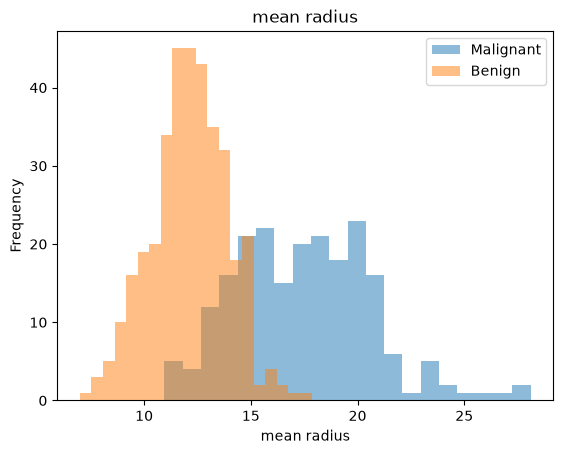

Feature:  mean texture
Malignant mean:  21.60490566037736
Benign mean:  17.914761904761903
Malignant variance:  14.217013670345317
Benign variance:  15.91631177804455
Separation score:  0.9506808633824383


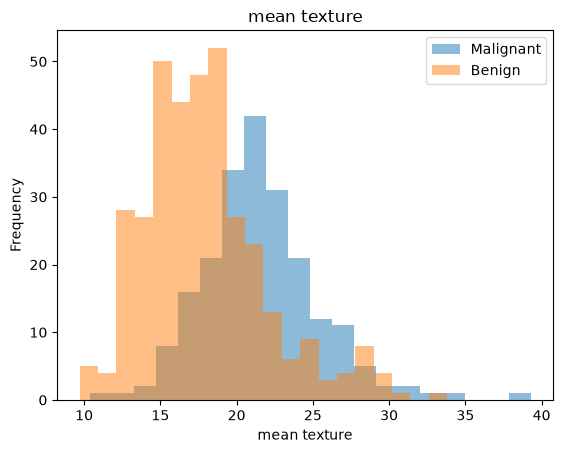

Feature:  mean smoothness
Malignant mean:  0.10289849056603775
Benign mean:  0.09247764705882354
Malignant variance:  0.00015821775526877893
Benign variance:  0.00018029056141044653
Separation score:  0.8010012618950054


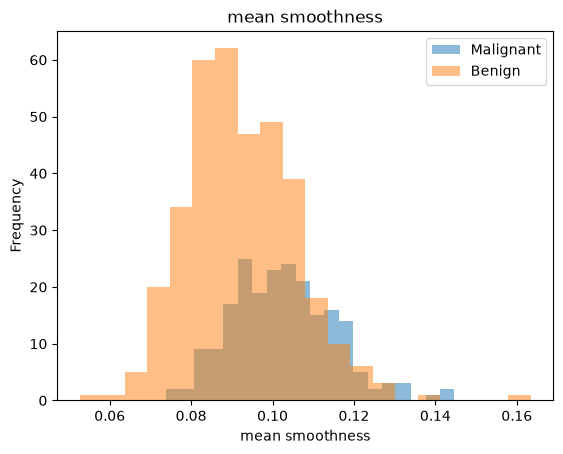

Feature:  mean concave points
Malignant mean:  0.08799
Benign mean:  0.025717406162464984
Malignant variance:  0.0011759921886792455
Benign variance:  0.00025238029607312724
Separation score:  2.330189364777056


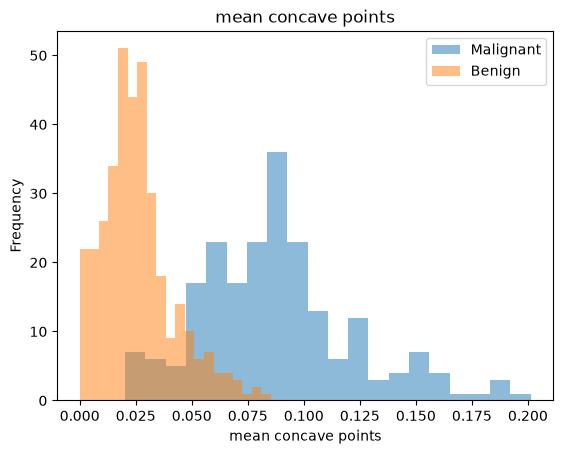

In [3]:
# B2.Four features
selected_features = ['mean radius', 'mean texture', 'mean smoothness', 'mean concave points']

for feature in selected_features:
    feature_data = x[:, data.feature_names == feature]
    malignant_feature_data = feature_data[y == 0]
    benign_feature_data = feature_data[y == 1]

    # calculate mean
    malignant_mean = np.mean(malignant_feature_data)
    benign_mean = np.mean(benign_feature_data)

    # calculate variance
    malignant_variance = np.var(malignant_feature_data)
    benign_variance = np.var(benign_feature_data)

    # calculate separation score
    separation = abs(malignant_mean - benign_mean) / np.sqrt((malignant_variance + benign_variance) / 2)

    print('Feature: ', feature)
    print('Malignant mean: ', malignant_mean)
    print('Benign mean: ', benign_mean)
    print('Malignant variance: ', malignant_variance)
    print('Benign variance: ', benign_variance)
    print('Separation score: ', separation)

    # Histogram
    plt.hist(malignant_feature_data, bins=20, alpha=0.5, label='Malignant')
    plt.hist(benign_feature_data, bins=20, alpha=0.5, label='Benign')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(feature)
    plt.legend()
    plt.show()

In [21]:
# B3.Standardize
# split
x_rest, x_test, y_rest, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_rest, y_rest, test_size=0.25, random_state=42, stratify=y_rest)

# calculate mean and standard deviation, using the training set only
# axis=0 means calculating along the columns, i.e., calculating the mean and standard deviation separately for each feature.
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

# standardize
x_train_std = (x_train - mean) / std
x_val_std = (x_val - mean) / std
x_test_std = (x_test - mean) / std

Best epoch:  29
Lowest validation loss:  0.10805454105138779
Final validation loss: 0.17486092448234558


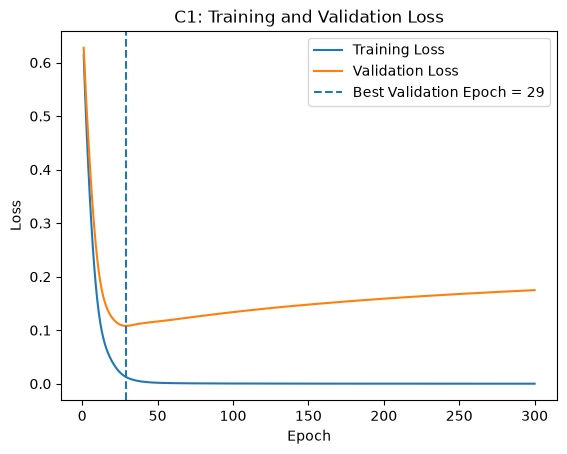

In [8]:
# C1.Break it
import torch
import torch.nn as nn

torch.manual_seed(42)

# data
x_train_60_tensor = torch.tensor(x_train_std[:60], dtype=torch.float32)
y_train_60_tensor = torch.tensor(y_train[:60], dtype=torch.float32).reshape(-1, 1)
x_val_tensor = torch.tensor(x_val_std, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# network 30->256(ReLU)->256(ReLU)->1
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(30, 256)
        self.layer2 = nn.Linear(256, 256)
        self.output = nn.Linear(256, 1)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.output(x)

        return x
    
model = NeuralNetwork() # model
criterion = nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer

# train
train_losses = []
val_losses = []

for epoch in range(300):
    # 1.----- train -----
    model.train()

    # forward pass
    output = model(x_train_60_tensor)

    # loss
    loss = criterion(output, y_train_60_tensor)

    # clear old gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

    # 2.----- evaluate -----
    model.eval()

    with torch.no_grad(): # no gradient calculation during evaluation
        # training loss
        train_output = model(x_train_60_tensor)
        train_loss = criterion(train_output, y_train_60_tensor)

        # validation loss
        val_output = model(x_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    # save loss
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

# lowest validation losdd
lowest_val_loss = min(val_losses)
best_epoch = val_losses.index(lowest_val_loss) + 1

print('Best epoch: ', best_epoch)
print('Lowest validation loss: ', lowest_val_loss)
print("Final validation loss:", val_losses[-1])

# plot training and validation loss
epochs = range(1, 301)

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

# Mark best validation epoch
plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best Validation Epoch = " + str(best_epoch)
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C1: Training and Validation Loss")
plt.legend()

plt.show()

Best epoch:  213
Lowest validation loss:  0.08997739851474762
Final validation loss: 0.09107533097267151


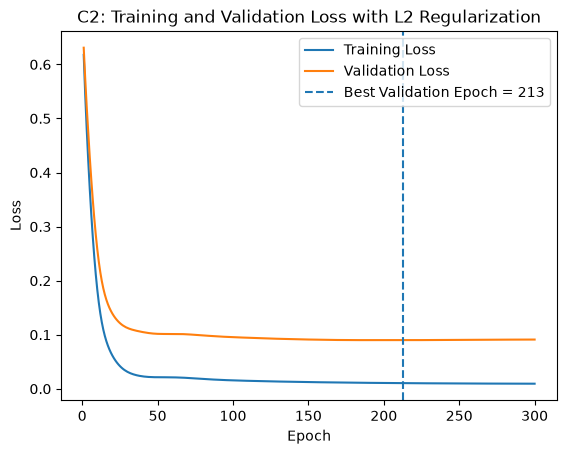

In [9]:
# C2.Fix it. L2 Regularization

import torch
import torch.nn as nn

torch.manual_seed(42)

# data
x_train_60_tensor = torch.tensor(x_train_std[:60], dtype=torch.float32)
y_train_60_tensor = torch.tensor(y_train[:60], dtype=torch.float32).reshape(-1, 1)
x_val_tensor = torch.tensor(x_val_std, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# network 30->256(ReLU)->256(ReLU)->1
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(30, 256)
        self.layer2 = nn.Linear(256, 256)
        self.output = nn.Linear(256, 1)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.output(x)

        return x
    
model_l2 = NeuralNetwork() # model
criterion = nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=0.01) # optimizer

# train
l2_train_losses = []
l2_val_losses = []

for epoch in range(300):
    # 1.----- train -----
    model_l2.train()

    # forward pass
    output = model_l2(x_train_60_tensor)

    # loss
    loss = criterion(output, y_train_60_tensor)

    # clear old gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

    # 2.----- evaluate -----
    model_l2.eval()

    with torch.no_grad(): # no gradient calculation during evaluation
        # training loss
        train_output = model_l2(x_train_60_tensor)
        train_loss = criterion(train_output, y_train_60_tensor)

        # validation loss
        val_output = model_l2(x_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    # save loss
    l2_train_losses.append(train_loss.item())
    l2_val_losses.append(val_loss.item())

# lowest validation losdd
l2_lowest_val_loss = min(l2_val_losses)
l2_best_epoch = l2_val_losses.index(l2_lowest_val_loss) + 1

print('Best epoch: ', l2_best_epoch)
print('Lowest validation loss: ', l2_lowest_val_loss)
print("Final validation loss:", l2_val_losses[-1])

# plot training and validation loss
epochs = range(1, 301)

plt.plot(epochs, l2_train_losses, label="Training Loss")
plt.plot(epochs, l2_val_losses, label="Validation Loss")

# Mark best validation epoch
plt.axvline(
    l2_best_epoch,
    linestyle="--",
    label="Best Validation Epoch = " + str(l2_best_epoch)
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C2: Training and Validation Loss with L2 Regularization")
plt.legend()

plt.show()

Best epoch:  37
Lowest validation loss:  0.1109263002872467
Final validation loss: 0.1648276001214981


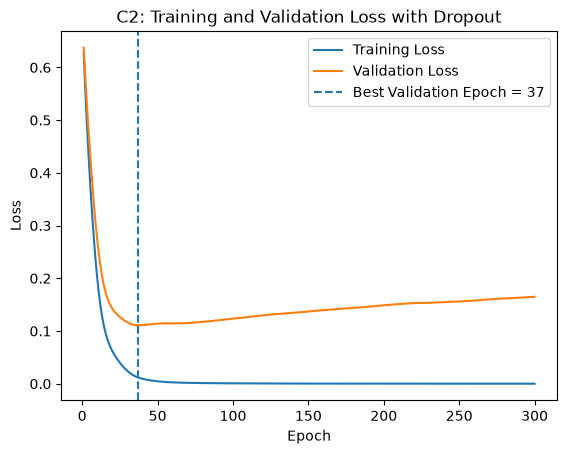

In [13]:
# C2.Fix it. Dropout
import torch
import torch.nn as nn

torch.manual_seed(42)

# data
x_train_60_tensor = torch.tensor(x_train_std[:60], dtype=torch.float32)
y_train_60_tensor = torch.tensor(y_train[:60], dtype=torch.float32).reshape(-1, 1)
x_val_tensor = torch.tensor(x_val_std, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# network
# 30->256(ReLU)->256(ReLU)->1
class DropoutNetwork(nn.Module):
    def __init__(self):

        super().__init__()

        self.layer1 = nn.Linear(30, 256)
        self.layer2 = nn.Linear(256, 256)
        self.output = nn.Linear(256, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.layer2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.output(x)

        return x

model_dropout = DropoutNetwork() # model
criterion = nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=0.001) # optimizer

# train
dropout_train_losses = []
dropout_val_losses = []

for epoch in range(300):
    # 1.----- train -----
    model_dropout.train()

    # forward pass
    output = model_dropout(x_train_60_tensor)

    # loss
    loss = criterion(output, y_train_60_tensor)

    # clear old gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

    # 2.----- evaluate -----
    model_dropout.eval()

    with torch.no_grad(): # no gradient calculation during evaluation
        # training loss
        train_output = model_dropout(x_train_60_tensor)
        train_loss = criterion(train_output, y_train_60_tensor)

        # validation loss
        val_output = model_dropout(x_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    # save loss
    dropout_train_losses.append(train_loss.item())
    dropout_val_losses.append(val_loss.item())

# lowest validation losdd
dropout_lowest_val_loss = min(dropout_val_losses)
dropout_best_epoch = dropout_val_losses.index(dropout_lowest_val_loss) + 1

print('Best epoch: ', dropout_best_epoch)
print('Lowest validation loss: ', dropout_lowest_val_loss)
print("Final validation loss:", dropout_val_losses[-1])

# plot training and validation loss
epochs = range(1, 301)

plt.plot(epochs, dropout_train_losses, label="Training Loss")
plt.plot(epochs, dropout_val_losses, label="Validation Loss")

# Mark best validation epoch
plt.axvline(
    dropout_best_epoch,
    linestyle="--",
    label="Best Validation Epoch = " + str(dropout_best_epoch)
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C2: Training and Validation Loss with Dropout")
plt.legend()

plt.show()

Early stopping at epoch: 49
Best epoch:  29
Lowest validation loss:  0.10805454105138779
Final validation loss: 0.10805454105138779


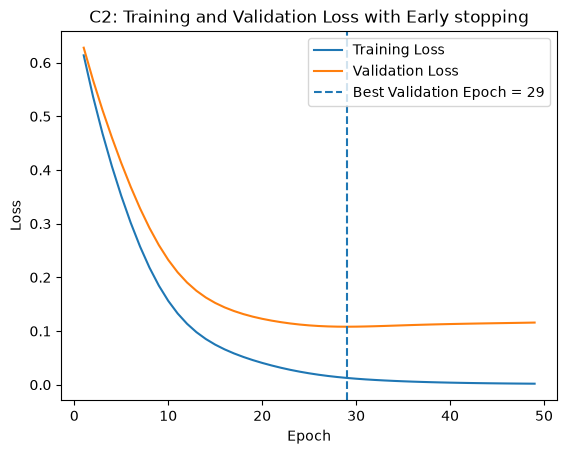

In [19]:
# C12.Fix it. Early stopping
import torch
import torch.nn as nn
import copy

torch.manual_seed(42)

# data
x_train_60_tensor = torch.tensor(x_train_std[:60], dtype=torch.float32)
y_train_60_tensor = torch.tensor(y_train[:60], dtype=torch.float32).reshape(-1, 1)
x_val_tensor = torch.tensor(x_val_std, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

# network 30->256(ReLU)->256(ReLU)->1
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(30, 256)
        self.layer2 = nn.Linear(256, 256)
        self.output = nn.Linear(256, 1)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.output(x)

        return x
    
model_es = NeuralNetwork() # model
criterion = nn.BCEWithLogitsLoss() # loss function
optimizer = torch.optim.Adam(model_es.parameters(), lr=0.001) # optimizer

# train
es_train_losses = []
es_val_losses = []

patience = 20
counter = 0

es_lowest_val_loss = float("inf")
es_best_epoch = 0
es_best_weights = None

for epoch in range(300):
    # 1.----- train -----
    model_es.train()

    # forward pass
    output = model_es(x_train_60_tensor)

    # loss
    loss = criterion(output, y_train_60_tensor)

    # clear old gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update
    optimizer.step()

    # 2.----- evaluate -----
    model_es.eval()

    with torch.no_grad(): # no gradient calculation during evaluation
        # training loss
        train_output = model_es(x_train_60_tensor)
        train_loss = criterion(train_output, y_train_60_tensor)

        # validation loss
        val_output = model_es(x_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)

    # save loss
    es_train_losses.append(train_loss.item())
    es_val_losses.append(val_loss.item())

    # Check whether validation loss improved
    if val_loss.item() < es_lowest_val_loss:
        es_lowest_val_loss = val_loss.item()
        es_best_epoch = epoch + 1

        # Save the best weights
        es_best_weights = copy.deepcopy(
            model_es.state_dict()
        )
        # Reset patience counter
        counter = 0
    else:
        counter += 1

    # Stop if validation loss has not improved
    # for 20 consecutive epochs
    if counter >= patience:
        print("Early stopping at epoch:", epoch + 1)
        break

print('Best epoch: ', es_best_epoch)
print('Lowest validation loss: ', es_lowest_val_loss)

# go back to the best weights
model_es.load_state_dict(es_best_weights)
model_es.eval()
with torch.no_grad():
    final_val_output = model_es(x_val_tensor)
    final_val_loss = criterion(
        final_val_output,
        y_val_tensor
    ).item()
print('Final validation loss:', es_best_val_loss)

# plot training and validation loss
epochs = range(1, len(es_train_losses) + 1)

plt.plot(epochs, es_train_losses, label="Training Loss")
plt.plot(epochs, es_val_losses, label="Validation Loss")

# Mark best validation epoch
plt.axvline(
    es_best_epoch,
    linestyle="--",
    label="Best Validation Epoch = " + str(es_best_epoch)
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C2: Training and Validation Loss with Early stopping")
plt.legend()

plt.show()

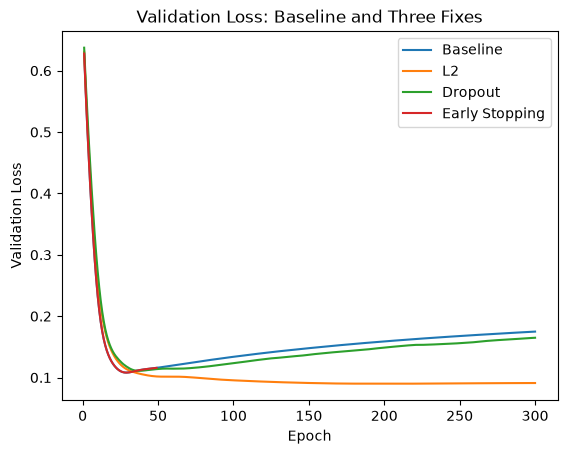

In [20]:
# validation loss of all four C1–C2 runs
plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="Baseline"
)

plt.plot(
    range(1, len(l2_val_losses) + 1),
    l2_val_losses,
    label="L2"
)

plt.plot(
    range(1, len(dropout_val_losses) + 1),
    dropout_val_losses,
    label="Dropout"
)

plt.plot(
    range(1, len(es_val_losses) + 1),
    es_val_losses,
    label="Early Stopping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline and Three Fixes")
plt.legend()

plt.show()

In [22]:
# C3 choose L2
# test data
x_test_tensor = torch.tensor(x_test_std, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# choose model_l2
# test
model_l2.eval()

with torch.no_grad():
    test_output = model_l2(x_test_tensor)
    test_prediction = (test_output >= 0).float()
    test_accuracy = (test_prediction == y_test_tensor).float().mean().item()

print("Test accuracy:", test_accuracy)
print("Test accuracy (%):", test_accuracy * 100)

Test accuracy: 0.9473684430122375
Test accuracy (%): 94.73684430122375
